In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import json

In [9]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "processed")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data path not found: {DATA_PATH}")

X_train = np.load(os.path.join(DATA_PATH, "X_train.npy"))
X_test  = np.load(os.path.join(DATA_PATH, "X_test.npy"))
y_train = np.load(os.path.join(DATA_PATH, "y_train.npy"))
y_test  = np.load(os.path.join(DATA_PATH, "y_test.npy"))
n_features = X_train.shape[1]
print(f"Loaded | Train: {X_train.shape[0]}, Test: {X_test.shape[0]}, Features: {n_features}")

Loaded | Train: 455, Test: 114, Features: 30


In [7]:
GA_CONFIG = {
    "pop_size": 50,
    "alpha": 1.0,
    "beta": 0.3,
    "max_features_ratio": 0.6,
    "penalty_weight": 2.0,
    "cv_folds": 3,
    "classifier": RandomForestClassifier(n_estimators=50, n_jobs=-1)
}
print(" GA Configuration loaded.")

 GA Configuration loaded.


In [10]:
def initialize_population(pop_size, n_features, method="uniform", seed=None):
    if seed is not None:
        np.random.seed(seed)

    if method == "uniform":
        return np.random.randint(0, 2, size=(pop_size, n_features))

    elif method == "sparse":
        prob_one = 0.2
        return np.random.choice([0, 1], size=(pop_size, n_features), p=[1-prob_one, prob_one])

    else:
        raise ValueError("method must be 'uniform' or 'sparse'")


test_pop = initialize_population(5, n_features, method="uniform")
print(" Sample Population (5 individuals):\n", test_pop)

 Sample Population (5 individuals):
 [[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 1 0 0 1 0 1 0 1 1]
 [1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 1 1 1 0 1 0 1 1 1 0 0 1 0 1 0]
 [0 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0]
 [1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1]
 [1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 0 1 1 0 0 1 0 0 1 0]]


In [11]:


def calculate_fitness(chromosome, X, y, config, seed=None):
    if seed is not None:
        np.random.seed(seed)

    selected_idx = np.where(chromosome == 1)[0]
    n_selected = len(selected_idx)
    n_total = len(chromosome)

    if n_selected == 0:
        return -10.0

    X_subset = X[:, selected_idx]

    clf = config["classifier"]
    try:
        acc = np.mean(cross_val_score(
            clf, X_subset, y,
            cv=config["cv_folds"],
            scoring="accuracy",
            n_jobs=-1
        ))
    except ValueError:
        acc = 0.0

    feature_ratio = n_selected / n_total
    base_fitness = config["alpha"] * acc - config["beta"] * feature_ratio

    max_allowed = int(n_total * config["max_features_ratio"])
    penalty = 0.0
    if n_selected > max_allowed:
        excess_ratio = (n_selected - max_allowed) / n_total
        penalty = config["penalty_weight"] * excess_ratio

    return base_fitness - penalty


def evaluate_population(population, X, y, config, seed=None):
    return np.array([calculate_fitness(ind, X, y, config, seed) for ind in population])

In [14]:
np.random.seed(42)

pop = initialize_population(GA_CONFIG["pop_size"], n_features, method="uniform")
fitness_vals = evaluate_population(pop, X_train, y_train, GA_CONFIG, seed=42)

print("Evaluation Test:")
print(f"Population Shape: {pop.shape}")
print(f"Fitness Stats: Mean={fitness_vals.mean():.3f} | Min={fitness_vals.min():.3f} | Max={fitness_vals.max():.3f}")
print(f"Best Individual: {pop[np.argmax(fitness_vals)]}")
print(f"Features Selected: {np.sum(pop[np.argmax(fitness_vals)])} / {n_features}")

Evaluation Test:
Population Shape: (50, 30)
Fitness Stats: Mean=0.785 | Min=0.388 | Max=0.864
Best Individual: [1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0]
Features Selected: 9 / 30


In [16]:
seeds = np.random.randint(0, 2**31, size=30).tolist()

SEEDS_PATH = os.path.join(DATA_PATH, "ga_seeds.json")
with open(SEEDS_PATH, "w") as f:
    json.dump(seeds, f)

print(f"Generated & saved {len(seeds)} random seeds to: {SEEDS_PATH}")

Generated & saved 30 random seeds to: d:\EA_Project\data\processed\ga_seeds.json


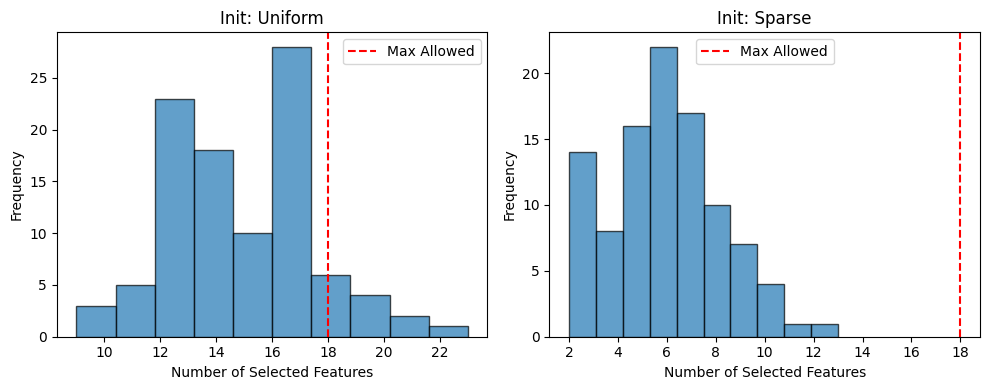

Visualization ready for report section: Effect of Initialization Strategies


In [17]:
methods = ["uniform", "sparse"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, method in enumerate(methods):
    pop = initialize_population(100, n_features, method=method, seed=42)
    features_count = np.sum(pop, axis=1)

    axes[i].hist(features_count, bins=10, alpha=0.7, edgecolor='black')
    axes[i].set_title(f"Init: {method.capitalize()}")
    axes[i].set_xlabel("Number of Selected Features")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(GA_CONFIG["max_features_ratio"] * n_features, color='r', linestyle='--', label="Max Allowed")
    axes[i].legend()

plt.tight_layout()
plt.show()

print("Visualization ready for report section: Effect of Initialization Strategies")